<a href="https://colab.research.google.com/github/margheritabenigni/DATASET-2-CHIMICA-Legami-e-Tavola-Periodica-/blob/main/ebollizione_codice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving ebollizione.csv.csv to ebollizione.csv.csv


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.linear_model import LinearRegression
from scipy import stats
import io
df = pd.read_csv(io.BytesIO(uploaded['ebollizione.csv.csv']))

print(df)

    Numero_Atomico  Massa_Molecolare  Polarita Tipo_Legame  \
0               21             179.0         0    Idrogeno   
1               48              86.7         0   Covalente   
2               20              53.2         0   Covalente   
3                8             159.5         1      Ionico   
4                7             135.6         0      Ionico   
5                3             171.7         0   Covalente   
6               17              62.2         0   Metallico   
7               33             101.3         1      Ionico   
8               48             104.7         0    Idrogeno   
9               12             176.5         0      Ionico   
10              51              17.3         1      Ionico   
11              22              57.8         1    Idrogeno   
12              55              37.6         1   Covalente   
13              22              51.3         0    Idrogeno   
14              46              89.4         0   Covalente   
15      

In [7]:
print("\n=== STATISTICA DESCRITTIVA ===")
print(df.describe())



=== STATISTICA DESCRITTIVA ===
       Numero_Atomico  Massa_Molecolare   Polarita  Punto_Ebollizione_C
count       38.000000         38.000000  38.000000            38.000000
mean        29.842105         85.300000   0.315789            81.497368
std         15.685294         50.276049   0.471069            55.483207
min          3.000000          4.900000   0.000000           -37.200000
25%         19.250000         49.650000   0.000000            42.400000
50%         30.000000         71.550000   0.000000            73.200000
75%         45.750000        120.200000   1.000000           128.450000
max         55.000000        179.000000   1.000000           197.900000


In [8]:
print("\nMedia ± Deviazione Standard")
for colonna in ['Numero_Atomico', 'Massa_Molecolare', 'Punto_Ebollizione_C']:
    media = df[colonna].mean()
    std = df[colonna].std()
    print(f"{colonna}: {media:.2f} ± {std:.2f}")


Media ± Deviazione Standard
Numero_Atomico: 29.84 ± 15.69
Massa_Molecolare: 85.30 ± 50.28
Punto_Ebollizione_C: 81.50 ± 55.48


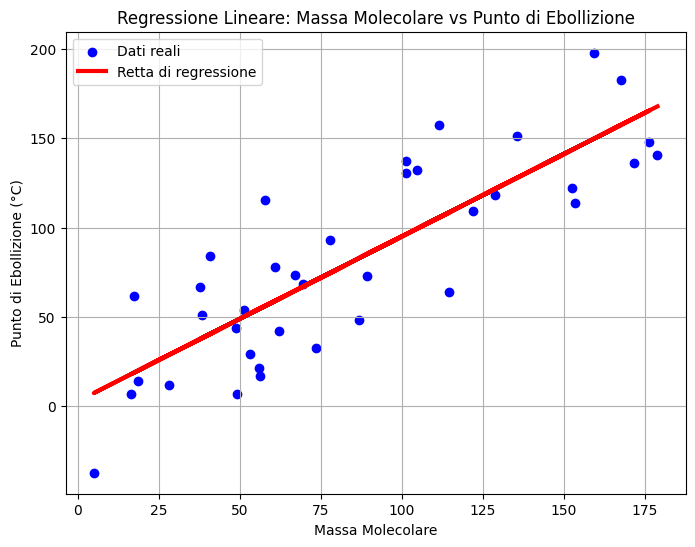

In [19]:
from sklearn.linear_model import LinearRegression

X = df[['Massa_Molecolare']]
y = df['Punto_Ebollizione_C']

model = LinearRegression()
model.fit(X, y)

plt.figure(figsize=(8,6))

plt.scatter(df['Massa_Molecolare'],
            df['Punto_Ebollizione_C'],
            color='blue',
            label='Dati reali')

plt.plot(df['Massa_Molecolare'],
         model.predict(X),
         color='red',
         linewidth=3,
         label='Retta di regressione')

plt.xlabel('Massa Molecolare')
plt.ylabel('Punto di Ebollizione (°C)')

plt.title('Regressione Lineare: Massa Molecolare vs Punto di Ebollizione')

plt.legend()
plt.grid(True)

plt.show()

In [10]:

X = df[['Massa_Molecolare']]
y = df['Punto_Ebollizione_C']

model = LinearRegression()
model.fit(X, y)

print("\n=== REGRESSIONE LINEARE SEMPLICE ===")

print(f"Intercetta (b0): {model.intercept_:.4f}")
print(f"Coefficiente Massa Molecolare (b1): {model.coef_[0]:.4f}")
print(f"R²: {model.score(X, y):.4f}")


=== REGRESSIONE LINEARE SEMPLICE ===
Intercetta (b0): 2.8688
Coefficiente Massa Molecolare (b1): 0.9218
R²: 0.6977


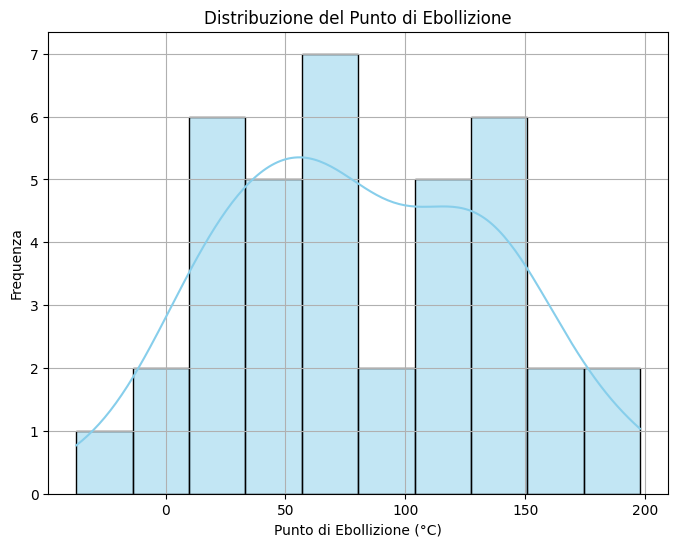

In [11]:

plt.figure(figsize=(8,6))
sns.histplot(df['Punto_Ebollizione_C'], bins=10, color='skyblue', kde=True)

plt.title('Distribuzione del Punto di Ebollizione')
plt.xlabel('Punto di Ebollizione (°C)')
plt.ylabel('Frequenza')

plt.grid(True)
plt.show()


In [12]:
df_dummies = pd.get_dummies(df,
                            columns=['Tipo_Legame'],
                            drop_first=True)

print("\nDataset con variabili dummy:")
print(df_dummies.head())


Dataset con variabili dummy:
   Numero_Atomico  Massa_Molecolare  Polarita  Punto_Ebollizione_C  \
0              21             179.0         0                140.8   
1              48              86.7         0                 48.4   
2              20              53.2         0                 29.3   
3               8             159.5         1                197.9   
4               7             135.6         0                151.2   

   Tipo_Legame_Idrogeno  Tipo_Legame_Ionico  Tipo_Legame_Metallico  
0                  True               False                  False  
1                 False               False                  False  
2                 False               False                  False  
3                 False                True                  False  
4                 False                True                  False  


In [13]:
X_multi = df_dummies.drop(columns=['Punto_Ebollizione_C'])

y = df_dummies['Punto_Ebollizione_C']

model_multi = LinearRegression()
model_multi.fit(X_multi, y)

print("\n=== REGRESSIONE MULTIPLA ===")

print("Coefficienti:")

for nome, coef in zip(X_multi.columns, model_multi.coef_):
    print(f"{nome}: {coef:.4f}")

print(f"\nIntercetta: {model_multi.intercept_:.4f}")

print(f"R²: {model_multi.score(X_multi, y):.4f}")


=== REGRESSIONE MULTIPLA ===
Coefficienti:
Numero_Atomico: -0.5455
Massa_Molecolare: 0.8470
Polarita: 51.4880
Tipo_Legame_Idrogeno: 12.9142
Tipo_Legame_Ionico: -1.5111
Tipo_Legame_Metallico: -7.0324

Intercetta: 7.6780
R²: 0.8938


/tmp/ipykernel_4648/1021711869.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Polarita',


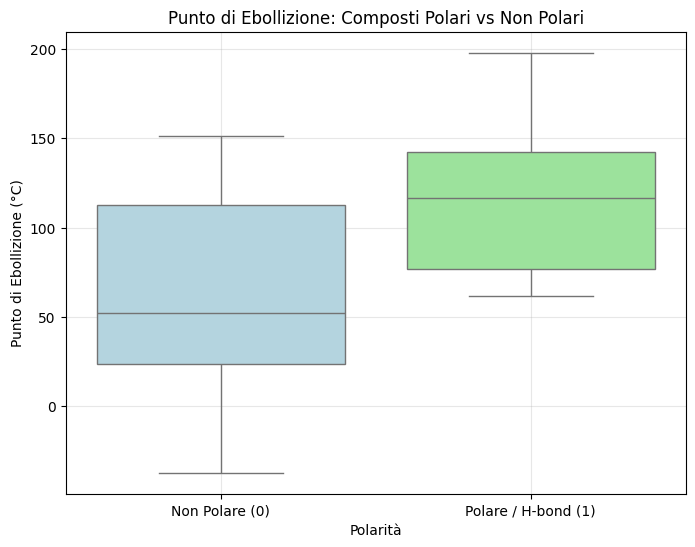

In [14]:

plt.figure(figsize=(8,6))

sns.boxplot(x='Polarita',
            y='Punto_Ebollizione_C',
            data=df,
            palette=['lightblue', 'lightgreen'])

plt.xticks([0,1],
           ['Non Polare (0)', 'Polare / H-bond (1)'])

plt.title('Punto di Ebollizione: Composti Polari vs Non Polari')

plt.xlabel('Polarità')
plt.ylabel('Punto di Ebollizione (°C)')

plt.grid(True, alpha=0.3)

plt.show()

In [15]:

gruppo0 = df[df['Polarita'] == 0]['Punto_Ebollizione_C']
gruppo1 = df[df['Polarita'] == 1]['Punto_Ebollizione_C']

t_stat, p_value = stats.ttest_ind(gruppo0, gruppo1)

print("\n=== RISULTATI T-TEST ===")

print(f"Media Non Polari : {gruppo0.mean():.3f}")
print(f"Media Polari     : {gruppo1.mean():.3f}")

print(f"t-statistic : {t_stat:.3f}")
print(f"p-value     : {p_value:.5f}")

if p_value < 0.05:
    print("→ Differenza statisticamente SIGNIFICATIVA!")
else:
    print("→ Differenza NON significativa")


=== RISULTATI T-TEST ===
Media Non Polari : 65.162
Media Polari     : 116.892
t-statistic : -2.933
p-value     : 0.00580
→ Differenza statisticamente SIGNIFICATIVA!


In [17]:
df['Polarita_Label'] = df['Polarita'].map({
    0: 'Non Polare',
    1: 'Polare'
})

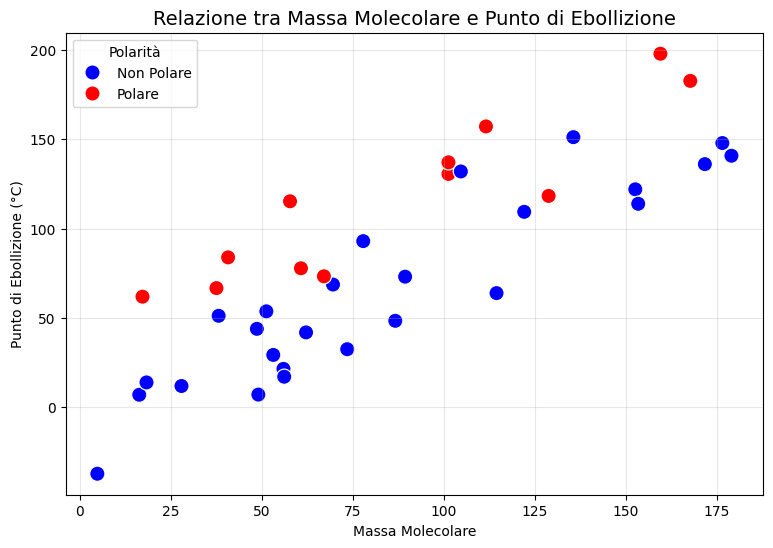

In [18]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x='Massa_Molecolare',
    y='Punto_Ebollizione_C',
    hue='Polarita_Label',
    palette={
        'Non Polare': 'blue',
        'Polare': 'red'
    },
    s=120
)

plt.title('Relazione tra Massa Molecolare e Punto di Ebollizione',
          fontsize=14)

plt.xlabel('Massa Molecolare')
plt.ylabel('Punto di Ebollizione (°C)')

plt.legend(title='Polarità')

plt.grid(True, alpha=0.3)

plt.show()